Data processing and plot creation for latitude and longitude of SCLF distribution

In [1]:
# load in tiles gpkg and folder with tif data

In [2]:
# get pixel count of 1 for each *.tif and add to geopackage

In [3]:
import geopandas as gpd
import pandas as pd
from osgeo import gdal
import numpy as np
import os
import re


In [4]:
# load 
gpkg_path = "./SCLF_tiles_greaterthan05_counts.gpkg"
gdf = gpd.read_file(gpkg_path)

In [5]:
from pyproj import Transformer

# Create the transformer
transformer = Transformer.from_crs("EPSG:3577", "EPSG:4326", always_xy=True)

def get_lat_lon(geometry):
    """Extract latitude and longitude from geometry centroid"""
    centroid = geometry.centroid
    lon, lat = transformer.transform(centroid.x, centroid.y)
    return pd.Series({'longitude': lon, 'latitude': lat})

# Apply the function
lat_lon_df = gdf.geometry.apply(get_lat_lon)
gdf = pd.concat([gdf, lat_lon_df], axis=1)

# Now round to nearest degree
gdf['longitude_deg'] = gdf['longitude'].round().astype(int)
gdf['latitude_deg'] = gdf['latitude'].round().astype(int)

gdf

,location,x,y,pixels_greaterthan05,greaterthan05_area_km2,geometry,longitude,latitude,longitude_deg,latitude_deg
0,x26y40_SCLF_model.tif,26,40,308,0.2772,"POLYGON ((-1920000.000 -2976000.000, -1824000....",112.900282,-26.616509,113,-27
1,x26y41_SCLF_model.tif,26,41,301,0.2709,"POLYGON ((-1920000.000 -2880000.000, -1824000....",113.044538,-25.769917,113,-26
2,x26y42_SCLF_model.tif,26,42,431,0.3879,"POLYGON ((-1920000.000 -2784000.000, -1824000....",113.186646,-24.922746,113,-25
3,x26y43_SCLF_model.tif,26,43,30668,27.6012,"POLYGON ((-1920000.000 -2688000.000, -1824000....",113.326655,-24.074826,113,-24
4,x26y44_SCLF_model.tif,26,44,18,0.0162,"POLYGON ((-1920000.000 -2592000.000, -1824000....",113.464610,-23.225987,113,-23
...,...,...,...,...,...,...,...,...,...,...
266,x67y40_SCLF_model.tif,67,40,272202,244.9818,"POLYGON ((2016000.000 -2976000.000, 2112000.00...",153.025077,-26.348772,153,-26
267,x67y41_SCLF_model.tif,67,41,474177,426.7593,"POLYGON ((2016000.000 -2880000.000, 2112000.00...",152.866778,-25.504065,153,-26
268,x67y42_SCLF_model.tif,67,42,106127,95.5143,"POLYGON ((2016000.000 -2784000.000, 2112000.00...",152.710824,-24.658696,153,-25
269,x68y41_SCLF_model.tif,68,41,498,0.4482,"POLYGON ((2112000.000 -2880000.000, 2208000.00...",153.818968,-25.361650,154,-25


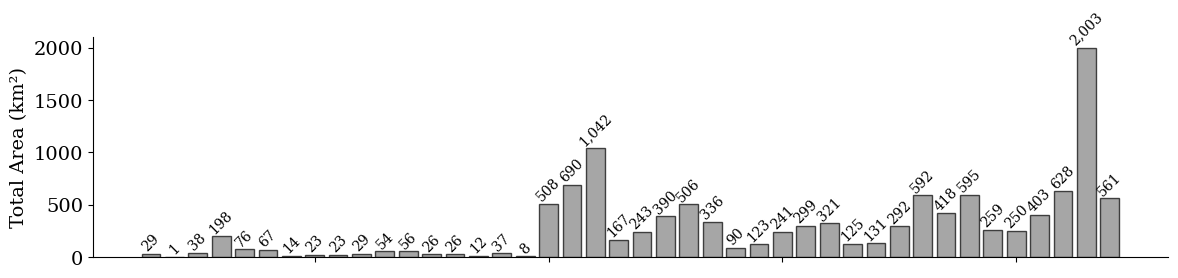

In [44]:
import matplotlib.pyplot as plt
import numpy as np

# Set font to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

# Simple histogram of area distribution by x coordinate
plt.figure(figsize=(12, 3))

# Group by x coordinate and sum area
area_by_longitude_deg = gdf.groupby('longitude_deg')['greaterthan05_area_km2'].sum()

# Create histogram
plt.bar(area_by_longitude_deg.index, area_by_longitude_deg.values, alpha=0.7, color='grey', edgecolor='black')
# plt.xlabel('Longitude')
plt.ylabel('Total Area (km²)')
# plt.title('Total Area across Longitude')
plt.grid(axis='y', alpha=0.3)

# Remove axis elements
# plt.xticks([])
plt.gca().set_xticklabels([])  # Remove tick labels
# plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
# plt.gca().spines['bottom'].set_visible(False)
# plt.gca().spines['left'].set_visible(False)

# Remove any grid
plt.grid(False)

# Add value labels on top of bars
for i, v in enumerate(area_by_longitude_deg.values):
    plt.text(area_by_longitude_deg.index[i], v, f'{v:,.0f}', ha='center', va='bottom', fontsize=10, rotation=45)

plt.tight_layout()
plt.savefig('area_by_longitude_deg_histogram.png', dpi=300)
plt.show()

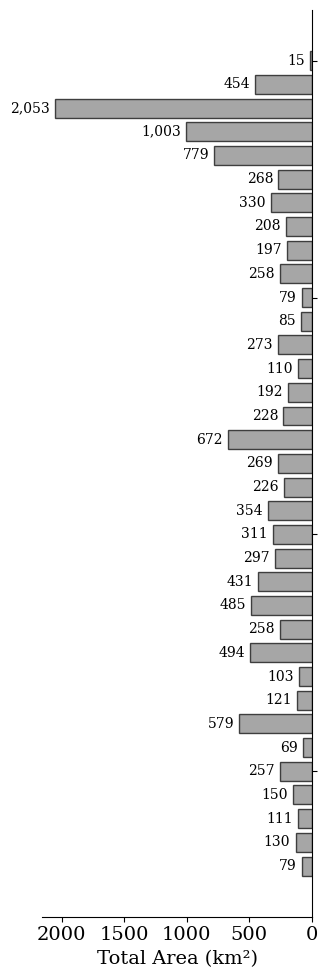

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Set font to Times New Roman
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

# Adjust figure size for horizontal bars
plt.figure(figsize=(3.5, 10))

# Group by x coordinate and sum area
area_by_latitude_deg = gdf.groupby('latitude_deg')['greaterthan05_area_km2'].sum()

# Create horizontal bar chart with bars going left
plt.barh(range(len(area_by_latitude_deg)), area_by_latitude_deg.values, 
         alpha=0.7, color='grey', edgecolor='black', left=0)

# Move y-axis to right side
plt.gca().yaxis.tick_right()
plt.gca().yaxis.set_label_position('right')

# Set y-ticks to specific latitude values (-10, -20, -30, -40)
# First, find which indices correspond to these latitudes
latitudes = area_by_latitude_deg.index
target_lats = [-10, -20, -30, -40]
y_positions = []
y_labels = []

for lat in target_lats:
    if lat in latitudes:
        idx = list(latitudes).index(lat)
        y_positions.append(idx)
        y_labels.append(str(lat))

# Set y-ticks only at specified latitudes
plt.yticks(y_positions, y_labels)
plt.gca().set_yticklabels([])

# Set x-ticks to specific values (2000, 1500, 1000, 0)
plt.xticks([2000, 1500, 1000, 500, 0])

# Set labels
plt.xlabel('Total Area (km²)')

# Reverse the x-axis so bars extend to the left
plt.gca().invert_xaxis()

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False) 
plt.gca().spines['right'].set_visible(True)
plt.gca().spines['bottom'].set_visible(True)

# Remove grid
plt.grid(False)

# Add value labels - position them to avoid overlap with bars
# Move them slightly to the left of the bar end
max_value = max(area_by_latitude_deg.values)
label_offset = max_value * -0.02  # 2% offset

for i, v in enumerate(area_by_latitude_deg.values):
    # Position text slightly left of the bar end to avoid overlap
    # Since x-axis is inverted, we subtract the offset
    label_x = v - label_offset
    plt.text(label_x, i, f'{v:,.0f}', ha='right', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('area_by_latitude_deg_histogram.png', dpi=300)
plt.show()